# 17 — Regresión anidada: comprobación de H2 y H3 (V2, diseño robusto)


1. **Transformamos la inflación con logaritmo** (media y volatilidad), porque unos pocos países con valores muy altos (Angola, RD Congo) podrían dominar el ajuste.
2. **Usamos 3 componentes por bloque**
3. **Medimos la estabilidad con bootstrap** (2.000 remuestreos)
El universo de países (172, excluyendo los 12 outliers monetarios de H1)

## 1. Importaciones y carga de datos

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy.stats import shapiro

pd.set_option("display.max_columns", None)


In [31]:
IN_PATH_PCA = Path("data/processed/15_pca_scores.xlsx")
IN_PATH_TARGET = Path("data/processed/14_pais_features.xlsx")

df_pca_scores = pd.read_excel(IN_PATH_PCA, sheet_name="pca_scores", index_col=0)
df_target_features = pd.read_excel(IN_PATH_TARGET, sheet_name="target_inflacion")
df_regiones = pd.read_excel("df_regiones_miembros_onu.xlsx")

print(f"Shape df_pca_scores: {df_pca_scores.shape}")
print(f"Shape df_target_features: {df_target_features.shape}")


Shape df_pca_scores: (184, 173)
Shape df_target_features: (193, 5)


**Qué comprobar:** que `df_pca_scores` tenga 184 filas. Si las rutas no coinciden con tu carpeta de trabajo, ajustalas — son las mismas de siempre.

## 2. Universo de países: exclusión de outliers monetarios

**Objetivo:** reconstruir los 12 países excluidos como outliers monetarios en H1, igual que en la versión anterior de este cuaderno — esto no cambia en el rediseño.

**Justificación metodológica:** mantenemos el mismo universo en H1, H2 y H3. Replicamos la regla ya documentada en el cuaderno 16 (distancia al centroide en el espacio MONETARIA + regla de Tukey), en vez de depender de un archivo exportado.

In [32]:
cols_monetaria = [c for c in df_pca_scores.columns if c.startswith("MONETARIA_")]
X_monetaria = df_pca_scores[cols_monetaria].copy()

centroide = X_monetaria.mean(axis=0)
distancia_centroide = np.linalg.norm(X_monetaria - centroide, axis=1)

df_distancias_monetaria = pd.DataFrame({
    "ISO-alpha3": X_monetaria.index,
    "distancia_centroide": distancia_centroide,
}).sort_values("distancia_centroide").reset_index(drop=True)

Q1 = df_distancias_monetaria["distancia_centroide"].quantile(0.25)
Q3 = df_distancias_monetaria["distancia_centroide"].quantile(0.75)
IQR = Q3 - Q1
umbral_tukey_monetaria = Q3 + 1.5 * IQR

paises_outlier_monetaria = df_distancias_monetaria.loc[
    df_distancias_monetaria["distancia_centroide"] > umbral_tukey_monetaria, "ISO-alpha3"
].tolist()

print(f"Paises excluidos ({len(paises_outlier_monetaria)}): {paises_outlier_monetaria}")


Paises excluidos (12): ['VEN', 'KIR', 'YEM', 'UZB', 'ISL', 'SSD', 'LBY', 'SDN', 'IRN', 'ZWE', 'SLE', 'TLS']


**Qué comprobar:** `len(paises_outlier_monetaria) == 12`, y que la lista coincida con la ya reportada en el cuaderno 16.

## 3. Construcción del dataset de trabajo (3 componentes por bloque)

**Objetivo:** armar la tabla de trabajo usando, para cada dimensión y estadístico, los primeros 3 componentes principales, más los 3 estadísticos de trayectoria de inflación.

**Resultado esperado:** `df_trabajo`, con hasta 36 columnas de componentes (4 dimensiones × 3 estadísticos × 3 componentes) más las 3 columnas de inflación.

In [33]:
DIMENSIONES = ["MONETARIA", "INSTITUCIONAL", "ESTRUCTURAL", "SOCIODEMOGRAFICA"]
ESTADISTICOS = ["media", "tendencia", "volatilidad"]

IN_PATH_K_RECOMENDADO = Path("data/processed/18_k_recomendado_por_bloque.xlsx")
df_k_recomendado = pd.read_excel(IN_PATH_K_RECOMENDADO)

N_COMPONENTES_POR_BLOQUE = {
    (fila["dimension"], fila["estadistico"]): int(fila["k_recomendado"])
    for _, fila in df_k_recomendado.iterrows()
}

def columnas_disponibles_bloque(df, dim, est, n_deseado):
    """Devuelve hasta n_deseado columnas PC del bloque, en orden (PC1, PC2, ...)."""
    patron = f"{dim}_{est}_PC"
    disponibles = sorted(
        [c for c in df.columns if c.startswith(patron) and c[len(patron):].isdigit()],
        key=lambda c: int(c[len(patron):])
    )
    return disponibles[:n_deseado]

cols_pca = {
    (dim, est): columnas_disponibles_bloque(df_pca_scores, dim, est, N_COMPONENTES_POR_BLOQUE[(dim, est)])
    for dim in DIMENSIONES for est in ESTADISTICOS
}

for (dim, est), cols in cols_pca.items():
    n_deseado = N_COMPONENTES_POR_BLOQUE[(dim, est)]
    if len(cols) < n_deseado:
        print(f"AVISO: {dim}_{est} solo tiene {len(cols)} componentes disponibles (se esperaban {n_deseado})")

todas_las_cols_pca = [c for cols in cols_pca.values() for c in cols]
print(f"Total de columnas de componentes usadas: {len(todas_las_cols_pca)}")
print(f"Componentes por bloque (criterio asimétrico, piso de varianza 30%):")
for (dim, est), n in sorted(N_COMPONENTES_POR_BLOQUE.items()):
    print(f"  {dim}_{est}: {n}")

Total de columnas de componentes usadas: 31
Componentes por bloque (criterio asimétrico, piso de varianza 30%):
  ESTRUCTURAL_media: 3
  ESTRUCTURAL_tendencia: 4
  ESTRUCTURAL_volatilidad: 2
  INSTITUCIONAL_media: 1
  INSTITUCIONAL_tendencia: 2
  INSTITUCIONAL_volatilidad: 1
  MONETARIA_media: 3
  MONETARIA_tendencia: 4
  MONETARIA_volatilidad: 3
  SOCIODEMOGRAFICA_media: 1
  SOCIODEMOGRAFICA_tendencia: 4
  SOCIODEMOGRAFICA_volatilidad: 3


In [34]:
df_target_indexado = df_target_features.set_index("ISO-alpha3")[["media", "tendencia", "volatilidad"]]

df_trabajo = df_pca_scores[todas_las_cols_pca].join(df_target_indexado, how="left")
df_trabajo = df_trabajo.drop(index=paises_outlier_monetaria, errors="ignore")

print(f"Shape df_trabajo (tras excluir outliers monetarios): {df_trabajo.shape}")
for est in ESTADISTICOS:
    print(f"  N con '{est}' de inflacion disponible: {df_trabajo[est].notna().sum()}")

n_pred_faltantes = df_trabajo[todas_las_cols_pca].isna().sum().sum()
print(f"\nValores faltantes en los predictores: {n_pred_faltantes} (esperado: 0)")


Shape df_trabajo (tras excluir outliers monetarios): (172, 34)
  N con 'media' de inflacion disponible: 167
  N con 'tendencia' de inflacion disponible: 166
  N con 'volatilidad' de inflacion disponible: 166

Valores faltantes en los predictores: 0 (esperado: 0)


**Qué comprobar:** shape total debería ser (172, 39) — 36 columnas de componentes + 3 de inflación. Los N por estadístico de inflación deberían rondar 167/166/166, igual que en H1. Los faltantes en predictores deberían ser 0.

## 4. Transformación logarítmica de la inflación

**Objetivo:** transformar `media` y `volatilidad` con logaritmo, para reducir el peso desproporcionado de los pocos países con valores muy extremos (ej. Angola, RD Congo), sin excluir a nadie.

**Justificación metodológica:** ambas variables son siempre positivas (o casi) y fuertemente asimétricas hacia la derecha — la mayoría de los países tiene valores chicos y unos pocos tienen valores mucho más altos que el resto. Esa asimetría genera inestabilidad. Aplicamos `log(1 + x/100)` a `media` (tratándola como una tasa, la transformación estándar para tasas en economía) y `log(1 + x)` a `volatilidad` (que no es una tasa sino una medida de dispersión, pero comparte el mismo problema de asimetría). No transformamos `tendencia` porque puede ser negativa y su media ya es cercana a cero — no tiene el mismo problema de cola larga hacia valores muy altos.

**Resultado esperado:** dos columnas nuevas, `media_log` y `volatilidad_log`, sin perder ningún país.

Rango de 'media': [0.10, 60.67]
Rango de 'volatilidad': [0.59, 116.81]


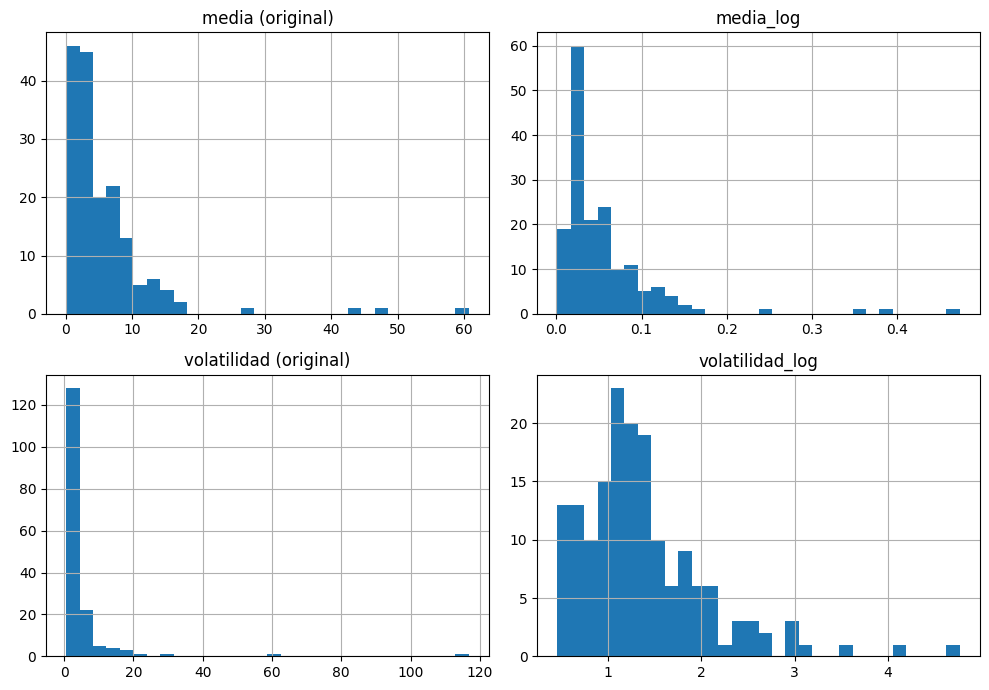

In [35]:
print(f"Rango de 'media': [{df_trabajo['media'].min():.2f}, {df_trabajo['media'].max():.2f}]")
print(f"Rango de 'volatilidad': [{df_trabajo['volatilidad'].min():.2f}, {df_trabajo['volatilidad'].max():.2f}]")

assert df_trabajo["media"].min() > -100, "Hay paises con 'media' <= -100%; no se puede aplicar log1p(x/100) sin ajustar"
assert df_trabajo["volatilidad"].min() >= 0, "La volatilidad no deberia tener valores negativos (es un desvio estandar)"

df_trabajo["media_log"] = np.log1p(df_trabajo["media"] / 100)
df_trabajo["volatilidad_log"] = np.log1p(df_trabajo["volatilidad"])

VARIABLE_Y = {"media": "media_log", "tendencia": "tendencia", "volatilidad": "volatilidad_log"}

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
df_trabajo["media"].hist(ax=axes[0, 0], bins=30)
axes[0, 0].set_title("media (original)")
df_trabajo["media_log"].hist(ax=axes[0, 1], bins=30)
axes[0, 1].set_title("media_log")
df_trabajo["volatilidad"].hist(ax=axes[1, 0], bins=30)
axes[1, 0].set_title("volatilidad (original)")
df_trabajo["volatilidad_log"].hist(ax=axes[1, 1], bins=30)
axes[1, 1].set_title("volatilidad_log")
plt.tight_layout()
plt.show()


## 5. Estandarización de los predictores

**Objetivo:** estandarizar (media 0, desvío 1) las 36 columnas de componentes, para que los coeficientes sean comparables.

**Justificación metodológica:** igual razón que en la versión anterior — sin estandarizar, comparar coeficientes entre dimensiones no tiene sentido.

In [36]:
for col in todas_las_cols_pca:
    df_trabajo[f"{col}_std"] = (df_trabajo[col] - df_trabajo[col].mean()) / df_trabajo[col].std()

# chequeo rapido
cols_std_ejemplo = [f"{c}_std" for c in todas_las_cols_pca[:4]]
df_trabajo[cols_std_ejemplo].agg(["mean", "std"]).round(3)


,MONETARIA_media_PC1_std,MONETARIA_media_PC2_std,MONETARIA_media_PC3_std,MONETARIA_tendencia_PC1_std
mean,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0


## 6. Verificación de orientación de los PC1

**Objetivo:** dejar registrada la lectura del signo de PC1 por dimensión (hecho a mano en el cuaderno 15).

H2 se testea a nivel de bloque completo (test F conjunto de los 3 componentes, sección 10), no coeficiente por coeficiente. El signo solo importa si, más adelante, un bloque resulta significativo y se quiere describir *en qué sentido* va el efecto — ahí sí conviene volver a esta nota.

- **INSTITUCIONAL_media:** PC1 alto = mejor calidad institucional.
- **ESTRUCTURAL_media:** PC1 alto = estructura más industrializada/asalariada.
- **SOCIODEMOGRAFICA_media:** PC1 alto = *peor* perfil sociodemográfico (más dependencia juvenil, más desnutrición) — signo invertido respecto de lo intuitivo.

(Ver cuaderno 15, sección 8, para el detalle completo con las cargas.)

## 7. Especificación y estimación de los modelos (A vs. B)

**Objetivo:** para cada estadístico, estimar el Modelo A (solo MONETARIA, 3 componentes) y el Modelo B (las 4 dimensiones, 12 componentes), usando ya la variable de inflación transformada cuando corresponde.

**Justificación metodológica:** misma lógica que antes, pero con bloques de 3 componentes por dimensión en vez de 1, y con `media`/`volatilidad` en su versión logarítmica.

In [37]:
def cols_para(estadistico, dimensiones):
    cols = []
    for dim in dimensiones:
        cols.extend([f"{c}_std" for c in cols_pca[(dim, estadistico)]])
    return cols

def preparar_xy(df, estadistico, dimensiones):
    cols_x = cols_para(estadistico, dimensiones)
    y_col = VARIABLE_Y[estadistico]
    df_sub = df.dropna(subset=[y_col]).copy()
    X = sm.add_constant(df_sub[cols_x])
    y = df_sub[y_col]
    return X, y, df_sub.index

modelos = {}

for estadistico in ESTADISTICOS:
    X_A, y_A, idx_A = preparar_xy(df_trabajo, estadistico, ["MONETARIA"])
    modelo_A = sm.OLS(y_A, X_A).fit()

    X_B, y_B, idx_B = preparar_xy(df_trabajo, estadistico, DIMENSIONES)
    modelo_B = sm.OLS(y_B, X_B).fit()

    assert list(idx_A) == list(idx_B), "Modelo A y B deberian correr sobre las mismas filas"

    modelos[estadistico] = {"A": modelo_A, "B": modelo_B, "n_obs": len(idx_A)}
    print(f"--- {estadistico} (n={len(idx_A)}, y={VARIABLE_Y[estadistico]}) ---")
    print(f"  Modelo A (solo MONETARIA, {modelo_A.df_model:.0f} predictores): R2 ajustado = {modelo_A.rsquared_adj:.3f}")
    print(f"  Modelo B (4 dimensiones, {modelo_B.df_model:.0f} predictores): R2 ajustado = {modelo_B.rsquared_adj:.3f}")


--- media (n=167, y=media_log) ---
  Modelo A (solo MONETARIA, 3 predictores): R2 ajustado = 0.108
  Modelo B (4 dimensiones, 8 predictores): R2 ajustado = 0.126
--- tendencia (n=166, y=tendencia) ---
  Modelo A (solo MONETARIA, 4 predictores): R2 ajustado = 0.013
  Modelo B (4 dimensiones, 14 predictores): R2 ajustado = 0.028
--- volatilidad (n=166, y=volatilidad_log) ---
  Modelo A (solo MONETARIA, 3 predictores): R2 ajustado = 0.274
  Modelo B (4 dimensiones, 9 predictores): R2 ajustado = 0.329


**Qué comprobar:** el N por estadístico debería ser el mismo de siempre (167/166/166). El número de predictores por bloque varía según el estadístico (criterio asimétrico de la sección 3), por eso se imprime dinámicamente en vez de fijarlo.

## 8. Diagnósticos del modelo completo (Modelo B)

**Objetivo:** mismo chequeo que antes (VIF, Breusch-Pagan, Shapiro-Wilk), ahora sobre los predictores del Modelo B.

**Justificación metodológica:** con más predictores por bloque, tiene más sentido todavía confirmar que no haya multicolinealidad severa entre ellos. Si Breusch-Pagan da significativo, reestimamos con errores robustos HC3, igual que en la versión anterior.

In [38]:
filas_diagnostico = []
modelos_reporte = {}

for estadistico in ESTADISTICOS:
    modelo_B = modelos[estadistico]["B"]
    X_B = modelo_B.model.exog
    nombres_X = modelo_B.model.exog_names

    vifs = {
        nombres_X[i]: variance_inflation_factor(X_B, i)
        for i in range(len(nombres_X)) if nombres_X[i] != "const"
    }
    vif_maximo = max(vifs.values())

    bp_stat, bp_pvalor, _, _ = het_breuschpagan(modelo_B.resid, X_B)
    sh_stat, sh_pvalor = shapiro(modelo_B.resid)

    necesita_robusto = bp_pvalor < 0.05
    if necesita_robusto:
        modelo_B_final = modelo_B.model.fit(cov_type="HC3")
    else:
        modelo_B_final = modelo_B

    modelos_reporte[estadistico] = modelo_B_final

    filas_diagnostico.append({
        "estadistico": estadistico,
        "vif_maximo": round(vif_maximo, 2),
        "bp_pvalor": round(bp_pvalor, 4),
        "shapiro_pvalor": round(sh_pvalor, 4),
        "usa_errores_robustos_HC3": necesita_robusto,
    })

df_diagnosticos = pd.DataFrame(filas_diagnostico)
df_diagnosticos


,estadistico,vif_maximo,bp_pvalor,shapiro_pvalor,usa_errores_robustos_HC3
0,media,10.29,0.2873,0.0,False
1,tendencia,2.35,0.3841,0.0,False
2,volatilidad,4.80,0.0032,0.0,True


**Qué comprobar:** `vif_maximo` bien por debajo de 5 en los tres estadísticos sería lo ideal. Si sigue alto en `media`, documentarlo igual que antes, pero recordá que ahora el R² y la significancia se leen a nivel de bloque (sección 10), no coeficiente por coeficiente, así que la multicolinealidad entre componentes individuales pesa un poco menos en la interpretación final.

## 9. Casos de alta influencia (informativo)

**Objetivo:** identificar, solo a modo informativo, qué países tienen mayor influencia sobre el Modelo B de cada estadístico.

**Justificación metodológica:** **no** vamos a reestimar el modelo excluyendo estos países a mano — esa práctica genera resultados poco confiables (un hallazgo que solo aparece al sacar 2-3 países elegidos por nosotras es un hallazgo frágil, no confirmado). En su lugar, en la sección 12 evaluamos la estabilidad general del resultado con bootstrap, que no depende de elegir a mano qué país sacar.

In [39]:
for estadistico in ESTADISTICOS:
    modelo_B = modelos[estadistico]["B"]
    influencia = OLSInfluence(modelo_B)
    cooks_d, _ = influencia.cooks_distance

    n_obs = modelos[estadistico]["n_obs"]
    umbral_cook = 4 / n_obs
    idx_influyentes = modelo_B.model.data.row_labels[cooks_d > umbral_cook]

    print(f"--- {estadistico} (umbral Cook = {umbral_cook:.4f}) ---")
    if len(idx_influyentes) == 0:
        print("  Sin paises por encima del umbral.")
    else:
        paises_influyentes = df_regiones.set_index("ISO-alpha3").reindex(idx_influyentes)["Member State"]
        print(f"  {len(idx_influyentes)} pais(es) por encima del umbral:")
        print(paises_influyentes.to_string())
    print()


--- media (umbral Cook = 0.0240) ---
  5 pais(es) por encima del umbral:
ISO-alpha3
AGO                              Angola
ARG                           Argentina
BLR                             Belarus
COD    Democratic Republic of the Congo
SUR                            Suriname

--- tendencia (umbral Cook = 0.0241) ---
  6 pais(es) por encima del umbral:
ISO-alpha3
AGO                              Angola
CHN                               China
CIV                       Cote d'Ivoire
COD    Democratic Republic of the Congo
GNQ                   Equatorial Guinea
TUR                            T��rkiye

--- volatilidad (umbral Cook = 0.0241) ---
  12 pais(es) por encima del umbral:
ISO-alpha3
AGO                              Angola
BLR                             Belarus
COD    Democratic Republic of the Congo
COG                               Congo
CYP                              Cyprus
ECU                             Ecuador
LSO                             Lesotho
MDV            

**Qué comprobar:** nada que requiera acción — es solo para tener presente, al redactar, qué países podrían estar influyendo más.

## 10. H2 — test de bloque por dimensión (F parcial)

**Objetivo:** para cada estadístico y cada dimensión no monetaria (INSTITUCIONAL, ESTRUCTURAL, SOCIODEMOGRAFICA), testear si el bloque completo de sus componentes aporta significativamente al modelo, controlando por las otras tres dimensiones (incluida MONETARIA).

**Justificación metodológica:** comparamos el Modelo B completo contra un modelo que le saca los componentes de una dimensión a la vez, con un test F anidado. Si ese test da significativo, la dimensión aporta algo como conjunto — sin necesitar interpretar el signo de cada componente por separado.

**Resultado esperado:** `df_resultados_h2`, con el F-stat y el p-valor del aporte de cada dimensión, por estadístico.

In [40]:
DIMENSIONES_NO_MONETARIAS = ["INSTITUCIONAL", "ESTRUCTURAL", "SOCIODEMOGRAFICA"]

filas_h2 = []

for estadistico in ESTADISTICOS:
    modelo_B = modelos[estadistico]["B"]

    for dim_testeada in DIMENSIONES_NO_MONETARIAS:
        dims_sin = [d for d in DIMENSIONES if d != dim_testeada]
        X_sin, y_sin, idx_sin = preparar_xy(df_trabajo, estadistico, dims_sin)
        modelo_sin = sm.OLS(y_sin, X_sin).fit()

        assert list(idx_sin) == list(modelo_B.model.data.row_labels), "Las filas deben coincidir entre modelos anidados"

        f_stat, f_pvalor, df_diff = modelo_B.compare_f_test(modelo_sin)

        filas_h2.append({
            "estadistico": estadistico,
            "dimension_testeada": dim_testeada,
            "f_stat": round(f_stat, 3),
            "f_pvalor": round(f_pvalor, 4),
            "significativo_0.05": f_pvalor < 0.05,
        })

df_resultados_h2 = pd.DataFrame(filas_h2)
df_resultados_h2


,estadistico,dimension_testeada,f_stat,f_pvalor,significativo_0.05
0,media,INSTITUCIONAL,0.045,0.8327,False
1,media,ESTRUCTURAL,2.048,0.1094,False
2,media,SOCIODEMOGRAFICA,0.244,0.6222,False
3,tendencia,INSTITUCIONAL,3.545,0.0313,True
4,tendencia,ESTRUCTURAL,0.149,0.9631,False
5,tendencia,SOCIODEMOGRAFICA,1.130,0.3444,False
6,volatilidad,INSTITUCIONAL,4.776,0.0303,True
7,volatilidad,ESTRUCTURAL,1.683,0.1891,False
8,volatilidad,SOCIODEMOGRAFICA,0.624,0.6002,False


**Qué comprobar:** el `assert` verifica que estemos comparando modelos sobre las mismas filas. Deberían aparecer 9 filas (3 dimensiones × 3 estadísticos). Fijate en `significativo_0.05`: eso es lo que responde directamente a H2, dimensión por dimensión.

## 11. H3 — comparación anidada (Modelo A vs. B)

**Objetivo:** comparar el modelo completo (4 dimensiones) contra el modelo restringido (solo MONETARIA).

In [41]:
filas_h3 = []

for estadistico in ESTADISTICOS:
    modelo_A = modelos[estadistico]["A"]
    modelo_B = modelos[estadistico]["B"]

    f_stat, f_pvalor, df_diff = modelo_B.compare_f_test(modelo_A)

    filas_h3.append({
        "estadistico": estadistico,
        "n_obs": modelos[estadistico]["n_obs"],
        "r2_adj_A_solo_monetaria": round(modelo_A.rsquared_adj, 3),
        "r2_adj_B_completo": round(modelo_B.rsquared_adj, 3),
        "delta_r2_adj": round(modelo_B.rsquared_adj - modelo_A.rsquared_adj, 3),
        "f_stat": round(f_stat, 3),
        "f_pvalor": round(f_pvalor, 4),
        "mejora_significativa_0.05": f_pvalor < 0.05,
    })

df_resultados_h3 = pd.DataFrame(filas_h3)
df_resultados_h3


,estadistico,n_obs,r2_adj_A_solo_monetaria,r2_adj_B_completo,delta_r2_adj,f_stat,f_pvalor,mejora_significativa_0.05
0,media,167,0.108,0.126,0.018,1.681,0.1422,False
1,tendencia,166,0.013,0.028,0.015,1.243,0.2684,False
2,volatilidad,166,0.274,0.329,0.056,3.236,0.0050,True


**Qué comprobar:** `delta_r2_adj` mide cuánto mejora el ajuste al sumar las tres dimensiones no monetarias por encima de lo que ya explica la dimensión monetaria sola.

## 12. Bootstrap de estabilidad (H2 y H3)

**Objetivo:** en vez de sacar países a mano y mirar si el resultado cambia, generamos 2.000 muestras alternativas (remuestreo con reposición, mismo N que la muestra original) y repetimos los tests de H2 y H3 en cada una. Así medimos en qué porcentaje de las muestras se sostiene cada conclusión.

**Justificación metodológica:** el bootstrap no depende de qué países decidamos excluir — cada una de las 2.000 muestras incluye una combinación distinta y aleatoria de países (algunos repetidos, algunos ausentes), así que el porcentaje de veces que un resultado se sostiene es una medida objetiva de estabilidad, no una elección nuestra.

**Cómo leerlo:** si una dimensión (o la mejora de H3) da significativa en, por ejemplo, el 85% de las 2.000 muestras, es un resultado bastante estable. Si da significativa en el 20%, es la definición misma de un resultado frágil. No hay un corte oficial único, pero como referencia orientativa: ≥80% lo tratamos como sólido, 50-79% como moderado, <50% como frágil.

**Resultado esperado:** dos tablas — el % de veces que cada dimensión resultó significativa en H2, y el % de veces que la mejora de H3 resultó significativa, por estadístico. Puede tardar uno o dos minutos en correr.

In [42]:
N_BOOTSTRAP = 2000
SEMILLA_BOOTSTRAP = 42

resultados_boot_h2 = {est: {dim: [] for dim in DIMENSIONES_NO_MONETARIAS} for est in ESTADISTICOS}
resultados_boot_h3 = {est: [] for est in ESTADISTICOS}

for estadistico in ESTADISTICOS:
    X_B_orig, y_B_orig, idx_B_orig = preparar_xy(df_trabajo, estadistico, DIMENSIONES)
    df_modelo = df_trabajo.loc[idx_B_orig].reset_index(drop=True)
    n = len(df_modelo)

    rng = np.random.default_rng(SEMILLA_BOOTSTRAP)

    print(f"--- Bootstrap para '{estadistico}' (n={n}, {N_BOOTSTRAP} remuestreos) ---")

    for b in range(N_BOOTSTRAP):
        idx_muestra = rng.integers(0, n, size=n)
        df_boot = df_modelo.iloc[idx_muestra]
        y_boot = df_boot[VARIABLE_Y[estadistico]].values

        X_A_boot = sm.add_constant(df_boot[cols_para(estadistico, ["MONETARIA"])].values)
        modelo_A_boot = sm.OLS(y_boot, X_A_boot).fit()

        X_B_boot = sm.add_constant(df_boot[cols_para(estadistico, DIMENSIONES)].values)
        modelo_B_boot = sm.OLS(y_boot, X_B_boot).fit()

        _, f_pvalor_h3, _ = modelo_B_boot.compare_f_test(modelo_A_boot)
        resultados_boot_h3[estadistico].append(f_pvalor_h3 < 0.05)

        for dim_testeada in DIMENSIONES_NO_MONETARIAS:
            dims_sin = [d for d in DIMENSIONES if d != dim_testeada]
            X_sin_boot = sm.add_constant(df_boot[cols_para(estadistico, dims_sin)].values)
            modelo_sin_boot = sm.OLS(y_boot, X_sin_boot).fit()
            _, f_pvalor_dim, _ = modelo_B_boot.compare_f_test(modelo_sin_boot)
            resultados_boot_h2[estadistico][dim_testeada].append(f_pvalor_dim < 0.05)

        if (b + 1) % 500 == 0:
            print(f"  {b + 1}/{N_BOOTSTRAP} remuestreos completados")

print("\nBootstrap terminado.")


--- Bootstrap para 'media' (n=167, 2000 remuestreos) ---
  500/2000 remuestreos completados
  1000/2000 remuestreos completados
  1500/2000 remuestreos completados
  2000/2000 remuestreos completados
--- Bootstrap para 'tendencia' (n=166, 2000 remuestreos) ---
  500/2000 remuestreos completados
  1000/2000 remuestreos completados
  1500/2000 remuestreos completados
  2000/2000 remuestreos completados
--- Bootstrap para 'volatilidad' (n=166, 2000 remuestreos) ---
  500/2000 remuestreos completados
  1000/2000 remuestreos completados
  1500/2000 remuestreos completados
  2000/2000 remuestreos completados

Bootstrap terminado.


In [43]:
filas_boot_h2 = []
for estadistico in ESTADISTICOS:
    for dim in DIMENSIONES_NO_MONETARIAS:
        pct = 100 * np.mean(resultados_boot_h2[estadistico][dim])
        filas_boot_h2.append({
            "estadistico": estadistico,
            "dimension_testeada": dim,
            "pct_significativo_en_bootstrap": round(pct, 1),
        })
df_boot_h2 = pd.DataFrame(filas_boot_h2)

filas_boot_h3 = []
for estadistico in ESTADISTICOS:
    pct = 100 * np.mean(resultados_boot_h3[estadistico])
    filas_boot_h3.append({
        "estadistico": estadistico,
        "pct_mejora_significativa_en_bootstrap": round(pct, 1),
    })
df_boot_h3 = pd.DataFrame(filas_boot_h3)

print("H2 - estabilidad por bootstrap:")
print(df_boot_h2)
print("\nH3 - estabilidad por bootstrap:")
print(df_boot_h3)


H2 - estabilidad por bootstrap:
   estadistico dimension_testeada  pct_significativo_en_bootstrap
0        media      INSTITUCIONAL                            11.6
1        media        ESTRUCTURAL                            47.2
2        media   SOCIODEMOGRAFICA                            14.4
3    tendencia      INSTITUCIONAL                            75.6
4    tendencia        ESTRUCTURAL                            25.0
5    tendencia   SOCIODEMOGRAFICA                            54.0
6  volatilidad      INSTITUCIONAL                            59.8
7  volatilidad        ESTRUCTURAL                            32.8
8  volatilidad   SOCIODEMOGRAFICA                            25.6

H3 - estabilidad por bootstrap:
   estadistico  pct_mejora_significativa_en_bootstrap
0        media                                   59.8
1    tendencia                                   69.3
2  volatilidad                                   95.2


**Qué comprobar:** estas son las tablas más importantes de todo el cuaderno. Un `pct_significativo_en_bootstrap` alto (≥80%) en alguna dimensión es evidencia sólida sobre H2 — mucho más confiable que cualquier p-valor aislado de la muestra completa. Un error típico acá sería un `ValueError` de dimensiones si `cols_para` devuelve una lista vacía.

## 13. Tabla consolidada de resultados

**Objetivo:** juntar, en una sola tabla por hipótesis, el resultado de la muestra completa y el porcentaje de estabilidad del bootstrap.

In [44]:
df_resultados_h2_final = df_resultados_h2.merge(
    df_boot_h2, on=["estadistico", "dimension_testeada"]
)
df_resultados_h2_final


,estadistico,dimension_testeada,f_stat,f_pvalor,significativo_0.05,pct_significativo_en_bootstrap
0,media,INSTITUCIONAL,0.045,0.8327,False,11.6
1,media,ESTRUCTURAL,2.048,0.1094,False,47.2
2,media,SOCIODEMOGRAFICA,0.244,0.6222,False,14.4
3,tendencia,INSTITUCIONAL,3.545,0.0313,True,75.6
4,tendencia,ESTRUCTURAL,0.149,0.9631,False,25.0
5,tendencia,SOCIODEMOGRAFICA,1.130,0.3444,False,54.0
6,volatilidad,INSTITUCIONAL,4.776,0.0303,True,59.8
7,volatilidad,ESTRUCTURAL,1.683,0.1891,False,32.8
8,volatilidad,SOCIODEMOGRAFICA,0.624,0.6002,False,25.6


In [45]:
df_resultados_h3_final = df_resultados_h3.merge(
    df_boot_h3, on="estadistico"
)
df_resultados_h3_final


,estadistico,n_obs,r2_adj_A_solo_monetaria,r2_adj_B_completo,delta_r2_adj,f_stat,f_pvalor,mejora_significativa_0.05,pct_mejora_significativa_en_bootstrap
0,media,167,0.108,0.126,0.018,1.681,0.1422,False,59.8
1,tendencia,166,0.013,0.028,0.015,1.243,0.2684,False,69.3
2,volatilidad,166,0.274,0.329,0.056,3.236,0.0050,True,95.2


**Qué comprobar:** un `significativo_0.05` en `True` con un `pct_significativo_en_bootstrap` bajo es exactamente el patrón de resultado frágil que hay que reportar como tal, no como hallazgo confirmado.

## 14. Chequeo robusto (errores HC3) para H2 y H3

**Objetivo:** repetir los tests de H2 y H3 usando errores robustos a heterocedasticidad (HC3) en vez de los clásicos, para las tres dimensiones no monetarias y para el bloque conjunto.

**Justificación metodológica:** en la sección 8 puede detectarse heterocedasticidad significativa en alguno de los modelos, pero los tests de bloque de las secciones 10 y 11, y el bootstrap de la sección 12, se corrieron con la versión clásica del modelo. Esta sección ajusta un único modelo por estadístico con `cov_type="HC3"` y testea cada bloque de coeficientes con un test de Wald robusto — equivalente en espíritu al test F anidado, pero válido incluso si hay heterocedasticidad.

**Resultado esperado:** las mismas 9 filas de H2 y 3 filas de H3, ahora con el p-valor robusto al lado del clásico.

In [46]:
def wald_test_bloque(modelo_robusto, nombres_bloque):
    """Test F conjunto, robusto a heterocedasticidad (HC3), de que los
    coeficientes de nombres_bloque son todos cero, sobre un modelo ya
    ajustado con cov_type='HC3'."""
    exog_names = modelo_robusto.model.exog_names
    k = len(exog_names)
    filas = []
    for nombre in nombres_bloque:
        fila = np.zeros(k)
        fila[exog_names.index(nombre)] = 1
        filas.append(fila)
    R = np.array(filas)
    resultado = modelo_robusto.wald_test(R, use_f=True)
    f_stat = float(np.asarray(resultado.statistic).squeeze())
    p_valor = float(np.asarray(resultado.pvalue).squeeze())
    return f_stat, p_valor


filas_h2_robusto = []
filas_h3_robusto = []

for estadistico in ESTADISTICOS:
    X_B, y_B, idx_B = preparar_xy(df_trabajo, estadistico, DIMENSIONES)
    modelo_B_robusto = sm.OLS(y_B, X_B).fit(cov_type="HC3")

    # H3 robusto: el bloque de las 3 dimensiones no monetarias, es cero?
    cols_no_monetarias = []
    for dim in DIMENSIONES_NO_MONETARIAS:
        cols_no_monetarias.extend(cols_para(estadistico, [dim]))
    f_stat_h3, p_valor_h3 = wald_test_bloque(modelo_B_robusto, cols_no_monetarias)
    filas_h3_robusto.append({
        "estadistico": estadistico,
        "f_stat_robusto": round(f_stat_h3, 3),
        "f_pvalor_robusto_HC3": round(p_valor_h3, 4),
        "significativo_robusto_0.05": p_valor_h3 < 0.05,
    })

    # H2 robusto: el bloque de cada dimension individual, es cero?
    for dim_testeada in DIMENSIONES_NO_MONETARIAS:
        cols_dim = cols_para(estadistico, [dim_testeada])
        f_stat_dim, p_valor_dim = wald_test_bloque(modelo_B_robusto, cols_dim)
        filas_h2_robusto.append({
            "estadistico": estadistico,
            "dimension_testeada": dim_testeada,
            "f_stat_robusto": round(f_stat_dim, 3),
            "f_pvalor_robusto_HC3": round(p_valor_dim, 4),
            "significativo_robusto_0.05": p_valor_dim < 0.05,
        })

df_h2_robusto = pd.DataFrame(filas_h2_robusto)
df_h3_robusto = pd.DataFrame(filas_h3_robusto)

print("H2 - version robusta (HC3):")
print(df_h2_robusto)
print("\nH3 - version robusta (HC3):")
print(df_h3_robusto)


H2 - version robusta (HC3):
   estadistico dimension_testeada  f_stat_robusto  f_pvalor_robusto_HC3  \
0        media      INSTITUCIONAL           0.033                0.8560   
1        media        ESTRUCTURAL           2.140                0.0974   
2        media   SOCIODEMOGRAFICA           0.145                0.7034   
3    tendencia      INSTITUCIONAL           2.053                0.1319   
4    tendencia        ESTRUCTURAL           0.157                0.9593   
5    tendencia   SOCIODEMOGRAFICA           0.577                0.6801   
6  volatilidad      INSTITUCIONAL           3.201                0.0755   
7  volatilidad        ESTRUCTURAL           0.984                0.3762   
8  volatilidad   SOCIODEMOGRAFICA           0.403                0.7514   

   significativo_robusto_0.05  
0                       False  
1                       False  
2                       False  
3                       False  
4                       False  
5                       False

**Qué comprobar:** deberían aparecer 9 filas en H2 y 3 en H3, igual que antes. Un error típico acá sería un `ValueError` si algún nombre de columna no está en `exog_names`.

## 15. Comparación clásico vs. robusto

**Objetivo:** juntar, en las tablas finales de la sección 13, el p-valor clásico, el % de estabilidad por bootstrap, y el p-valor robusto — para ver de un vistazo si la corrección por heterocedasticidad cambia alguna conclusión.

In [47]:
df_resultados_h2_final = df_resultados_h2_final.merge(
    df_h2_robusto, on=["estadistico", "dimension_testeada"]
)
df_resultados_h2_final


,estadistico,dimension_testeada,f_stat,f_pvalor,significativo_0.05,pct_significativo_en_bootstrap,f_stat_robusto,f_pvalor_robusto_HC3,significativo_robusto_0.05
0,media,INSTITUCIONAL,0.045,0.8327,False,11.6,0.033,0.8560,False
1,media,ESTRUCTURAL,2.048,0.1094,False,47.2,2.140,0.0974,False
2,media,SOCIODEMOGRAFICA,0.244,0.6222,False,14.4,0.145,0.7034,False
3,tendencia,INSTITUCIONAL,3.545,0.0313,True,75.6,2.053,0.1319,False
4,tendencia,ESTRUCTURAL,0.149,0.9631,False,25.0,0.157,0.9593,False
5,tendencia,SOCIODEMOGRAFICA,1.130,0.3444,False,54.0,0.577,0.6801,False
6,volatilidad,INSTITUCIONAL,4.776,0.0303,True,59.8,3.201,0.0755,False
7,volatilidad,ESTRUCTURAL,1.683,0.1891,False,32.8,0.984,0.3762,False
8,volatilidad,SOCIODEMOGRAFICA,0.624,0.6002,False,25.6,0.403,0.7514,False


In [48]:
df_resultados_h3_final = df_resultados_h3_final.merge(
    df_h3_robusto, on="estadistico"
)
df_resultados_h3_final


,estadistico,n_obs,r2_adj_A_solo_monetaria,r2_adj_B_completo,delta_r2_adj,f_stat,f_pvalor,mejora_significativa_0.05,pct_mejora_significativa_en_bootstrap,f_stat_robusto,f_pvalor_robusto_HC3,significativo_robusto_0.05
0,media,167,0.108,0.126,0.018,1.681,0.1422,False,59.8,2.077,0.0711,False
1,tendencia,166,0.013,0.028,0.015,1.243,0.2684,False,69.3,0.911,0.5247,False
2,volatilidad,166,0.274,0.329,0.056,3.236,0.0050,True,95.2,3.193,0.0055,True


**Qué comprobar:** compará `significativo_0.05` (clásico) contra `significativo_robusto_0.05` (HC3) en cada fila. Si alguna fila cambia de `True` a `False` (o viceversa) al pasar a la versión robusta, priorizá la versión robusta como la válida — es la que no asume homocedasticidad.

## 16. Exportación de resultados

Bloque comentado por defecto.

In [49]:
# OUT_PATH = Path("data/processed/17_resultados_h2_h3_v2.xlsx")
# with pd.ExcelWriter(OUT_PATH) as writer:
#     df_resultados_h2_final.to_excel(writer, sheet_name="resultados_h2", index=False)
#     df_resultados_h3_final.to_excel(writer, sheet_name="resultados_h3", index=False)
#     df_diagnosticos.to_excel(writer, sheet_name="diagnosticos", index=False)
# print(f"Guardado en {OUT_PATH}")


## 17. Vamos a hacer unas tablas y graficos más prolijos para el informe final

In [50]:
tabla_h2_informe = df_resultados_h2_final.rename(columns={
    "estadistico": "Estadístico",
    "dimension_testeada": "Dimensión",
    "f_pvalor": "p (clásico)",
    "significativo_0.05": "Significativo (clásico)",
    "pct_significativo_en_bootstrap": "% estable en bootstrap",
    "f_pvalor_robusto_HC3": "p (robusto HC3)",
    "significativo_robusto_0.05": "Significativo (robusto)",
})[[
    "Estadístico", "Dimensión",
    "p (clásico)", "Significativo (clásico)",
    "% estable en bootstrap",
    "p (robusto HC3)", "Significativo (robusto)",
]]

tabla_h3_informe = df_resultados_h3_final.rename(columns={
    "estadistico": "Estadístico",
    "n_obs": "N",
    "r2_adj_A_solo_monetaria": "R² ajustado (solo monetaria)",
    "r2_adj_B_completo": "R² ajustado (completo)",
    "delta_r2_adj": "ΔR² ajustado",
    "f_pvalor": "p (clásico)",
    "mejora_significativa_0.05": "Mejora significativa (clásico)",
    "pct_mejora_significativa_en_bootstrap": "% estable en bootstrap",
    "f_pvalor_robusto_HC3": "p (robusto HC3)",
    "significativo_robusto_0.05": "Mejora significativa (robusto)",
})

if "tablas_reporte" not in dir():
    tablas_reporte = {}
tablas_reporte["H2_test_de_bloque"] = tabla_h2_informe
tablas_reporte["H3_comparacion_anidada"] = tabla_h3_informe

for nombre, tabla in tablas_reporte.items():
    print(f"=== {nombre} ===")
    print(tabla.to_string(index=False))
    print()

OUT_PATH_INFORME = Path("data/processed/17_tablas_informe.xlsx")
with pd.ExcelWriter(OUT_PATH_INFORME) as writer:
    for nombre, tabla in tablas_reporte.items():
        tabla.to_excel(writer, sheet_name=nombre[:31], index=False)
print(f"Tablas exportadas a {OUT_PATH_INFORME}")

=== H2_test_de_bloque ===
Estadístico        Dimensión  p (clásico)  Significativo (clásico)  % estable en bootstrap  p (robusto HC3)  Significativo (robusto)
      media    INSTITUCIONAL       0.8327                    False                    11.6           0.8560                    False
      media      ESTRUCTURAL       0.1094                    False                    47.2           0.0974                    False
      media SOCIODEMOGRAFICA       0.6222                    False                    14.4           0.7034                    False
  tendencia    INSTITUCIONAL       0.0313                     True                    75.6           0.1319                    False
  tendencia      ESTRUCTURAL       0.9631                    False                    25.0           0.9593                    False
  tendencia SOCIODEMOGRAFICA       0.3444                    False                    54.0           0.6801                    False
volatilidad    INSTITUCIONAL       0.0303  

In [59]:
import pandas as pd
import plotly.graph_objects as go
from pathlib import Path

# Carga desde el archivo ya exportado por este cuaderno (no se recalcula nada)
IN_PATH = Path("data/processed/17_tablas_informe.xlsx")
tabla_h2 = pd.read_excel(IN_PATH, sheet_name="H2_test_de_bloque")
tabla_h3 = pd.read_excel(IN_PATH, sheet_name="H3_comparacion_anidada")

filas_grafico = []
for _, fila in tabla_h2.iterrows():
    filas_grafico.append({
        "etiqueta": f"{fila['Dimensión'].title()} — {fila['Estadístico']} (H2)",
        "pct_bootstrap": fila["% estable en bootstrap"],
        "robusto": fila["Significativo (robusto)"] in [True, "VERDADERO", "True"],
    })

for _, fila in tabla_h3.iterrows():
    filas_grafico.append({
        "etiqueta": f"Las 3 dimensiones juntas — {fila['Estadístico']} (H3)",
        "pct_bootstrap": fila["% estable en bootstrap"],
        "robusto": fila["Mejora significativa (robusto)"] in [True, "VERDADERO", "True"],
    })

df_grafico = pd.DataFrame(filas_grafico).sort_values("pct_bootstrap", ascending=True)
colores = df_grafico["robusto"].map({True: "#2E7D32", False: "#B0B0B0"})

fig_estabilidad = go.Figure()
fig_estabilidad.add_trace(go.Bar(
    x=df_grafico["pct_bootstrap"], y=df_grafico["etiqueta"], orientation="h",
    marker_color=colores,
    text=df_grafico["pct_bootstrap"].round(1).astype(str) + "%",
    textposition="outside",
))
fig_estabilidad.add_vline(x=50, line_dash="dot", line_color="gray", annotation_text="50%", annotation_position="top")
fig_estabilidad.add_vline(x=80, line_dash="dash", line_color="black", annotation_text="80%", annotation_position="top")
fig_estabilidad.update_layout(
    title="Estabilidad por bootstrap de las pruebas de H2 y H3<br><sup>Verde = también significativo en el test robusto (HC3)</sup>",
    xaxis_title="% de las 2.000 muestras de bootstrap en que el resultado fue significativo",
    yaxis_title="", xaxis_range=[0, 105], height=500, margin=dict(l=260),
)
fig_estabilidad.show()

## 18. Tablas para el informe

Esta sección arma, para el Modelo A y el Modelo B de cada estadístico, las tablas que van directamente en Resultados: coeficientes, ajuste global y diagnósticos, más una tabla comparativa A vs. B. No se recalcula nada de lo ya obtenido en las secciones anteriores salvo los diagnósticos del Modelo A, que hasta ahora solo existían para el Modelo B.

### 18.1 Diagnósticos del Modelo A

**Objetivo:** calcular VIF, Breusch-Pagan y Shapiro-Wilk para el Modelo A de cada estadístico, con el mismo criterio que ya se aplicó al Modelo B en la sección 8.

**Justificación metodológica:** para poder reportar el Modelo A con el mismo nivel de detalle que el Modelo B (coeficientes con sus errores correctos, R² y prueba F), primero hay que saber si sus residuos son homocedásticos. Si Breusch-Pagan da significativo, se reestima con errores robustos HC3, igual que se hizo con el Modelo B.

**Resultado esperado:** `df_diagnosticos_A` y `modelos_A_reporte` (el modelo final —clásico o robusto— que se usa en el resto de la sección).

In [52]:
filas_diagnostico_A = []
modelos_A_reporte = {}

for estadistico in ESTADISTICOS:
    modelo_A = modelos[estadistico]["A"]
    X_A = modelo_A.model.exog
    nombres_X_A = modelo_A.model.exog_names

    vifs_A = {
        nombres_X_A[i]: variance_inflation_factor(X_A, i)
        for i in range(len(nombres_X_A)) if nombres_X_A[i] != "const"
    }
    vif_maximo_A = max(vifs_A.values())

    bp_stat_A, bp_pvalor_A, _, _ = het_breuschpagan(modelo_A.resid, X_A)
    sh_stat_A, sh_pvalor_A = shapiro(modelo_A.resid)

    necesita_robusto_A = bp_pvalor_A < 0.05
    if necesita_robusto_A:
        modelo_A_final = modelo_A.model.fit(cov_type="HC3")
    else:
        modelo_A_final = modelo_A

    modelos_A_reporte[estadistico] = modelo_A_final

    filas_diagnostico_A.append({
        "estadistico": estadistico,
        "vif_maximo": round(vif_maximo_A, 2),
        "bp_pvalor": round(bp_pvalor_A, 4),
        "shapiro_pvalor": round(sh_pvalor_A, 4),
        "usa_errores_robustos_HC3": necesita_robusto_A,
    })

df_diagnosticos_A = pd.DataFrame(filas_diagnostico_A)
df_diagnosticos_A


,estadistico,vif_maximo,bp_pvalor,shapiro_pvalor,usa_errores_robustos_HC3
0,media,1.04,0.1610,0.0,False
1,tendencia,1.38,0.2930,0.0,False
2,volatilidad,1.24,0.0016,0.0,True


**Qué comprobar:** que `vif_maximo` no sea extremo (la dimensión MONETARIA sola tiene menos predictores que el Modelo B, así que en general debería dar más bajo). Si `usa_errores_robustos_HC3` da `True` en algún estadístico, los coeficientes de esa fila en la sección 18.2 van a mostrar los errores estándar robustos, no los clásicos.

### 18.2 Coeficientes estimados (Modelo A y Modelo B)

**Objetivo:** extraer, para cada predictor de cada estadístico, el coeficiente, el error estándar, el estadístico t y el p-valor — usando siempre el modelo final (clásico o robusto HC3 según correspondió en los diagnósticos).

**Justificación metodológica:** estos valores ya estaban calculados dentro de cada modelo ajustado; acá simplemente se extraen y ordenan en una tabla, sin reajustar nada.

**Resultado esperado:** `df_coeficientes_A` y `df_coeficientes_B`, una fila por predictor (incluida la constante) y estadístico.

In [53]:
def tabla_coeficientes(modelos_reporte_dict, estadisticos):
    filas = []
    for estadistico in estadisticos:
        modelo = modelos_reporte_dict[estadistico]
        for variable, coef, se, t, p in zip(
            modelo.model.exog_names, modelo.params, modelo.bse, modelo.tvalues, modelo.pvalues
        ):
            filas.append({
                "estadistico": estadistico,
                "variable": variable,
                "coeficiente": round(coef, 4),
                "error_estandar": round(se, 4),
                "t": round(t, 3),
                "p_valor": round(p, 4),
            })
    return pd.DataFrame(filas)

df_coeficientes_A = tabla_coeficientes(modelos_A_reporte, ESTADISTICOS)
df_coeficientes_B = tabla_coeficientes(modelos_reporte, ESTADISTICOS)

df_coeficientes_A


,estadistico,variable,coeficiente,error_estandar,t,p_valor
0,media,const,0.0553,0.0045,12.334,0.0000
1,media,MONETARIA_media_PC1_std,-0.0221,0.0046,-4.794,0.0000
2,media,MONETARIA_media_PC2_std,-0.0006,0.0046,-0.141,0.8883
3,media,MONETARIA_media_PC3_std,-0.0036,0.0048,-0.738,0.4613
4,tendencia,const,-0.3500,0.1152,-3.038,0.0028
5,tendencia,MONETARIA_tendencia_PC1_std,-0.1343,0.1300,-1.033,0.3030
6,tendencia,MONETARIA_tendencia_PC2_std,-0.0721,0.1402,-0.514,0.6076
7,tendencia,MONETARIA_tendencia_PC3_std,-0.0897,0.1213,-0.740,0.4605
8,tendencia,MONETARIA_tendencia_PC4_std,0.2605,0.1226,2.125,0.0351
9,volatilidad,const,1.3822,0.0462,29.912,0.0000


In [54]:
df_coeficientes_B


,estadistico,variable,coeficiente,error_estandar,t,p_valor
0,media,const,0.0558,0.0044,12.538,0.0000
1,media,MONETARIA_media_PC1_std,-0.0076,0.0134,-0.570,0.5692
2,media,MONETARIA_media_PC2_std,-0.0123,0.0075,-1.633,0.1045
3,media,MONETARIA_media_PC3_std,-0.0071,0.0053,-1.326,0.1867
4,media,INSTITUCIONAL_media_PC1_std,-0.0021,0.0100,-0.212,0.8327
5,media,ESTRUCTURAL_media_PC1_std,-0.0179,0.0142,-1.258,0.2103
6,media,ESTRUCTURAL_media_PC2_std,0.0186,0.0082,2.264,0.0249
7,media,ESTRUCTURAL_media_PC3_std,-0.0018,0.0055,-0.337,0.7364
8,media,SOCIODEMOGRAFICA_media_PC1_std,-0.0058,0.0117,-0.494,0.6222
9,tendencia,const,-0.3515,0.1144,-3.072,0.0025


**Qué comprobar:** el número de filas de `df_coeficientes_A` por estadístico debería ser `k_predictores + 1` (la constante incluida), y coincidir con el `k` de la dimensión MONETARIA de cada estadístico. En `df_coeficientes_B` debería aparecer una fila por cada predictor de las 4 dimensiones más la constante.

### 18.3 Tabla resumen del modelo (Modelo A y Modelo B)

**Objetivo:** una fila por estadístico con el tamaño muestral, la cantidad de predictores, R², R² ajustado, la prueba F global y los diagnósticos de la sección correspondiente.

**Justificación metodológica:** junta en un solo lugar los números de ajuste global que van a citarse en el texto de Resultados, para no tener que ir a buscarlos a distintas secciones.

**Resultado esperado:** `df_resumen_A` y `df_resumen_B`.

In [55]:
def tabla_resumen(modelos_reporte_dict, diagnosticos_df, estadisticos):
    filas = []
    for estadistico in estadisticos:
        modelo_final = modelos_reporte_dict[estadistico]
        filas.append({
            "estadistico": estadistico,
            "n_obs": modelos[estadistico]["n_obs"],
            "k_predictores": int(modelo_final.df_model),
            "r2": round(modelo_final.rsquared, 3),
            "r2_ajustado": round(modelo_final.rsquared_adj, 3),
            "f_stat": round(modelo_final.fvalue, 3),
            "f_pvalor": round(modelo_final.f_pvalue, 4),
        })
    df_resumen = pd.DataFrame(filas)
    return df_resumen.merge(diagnosticos_df, on="estadistico")

df_resumen_A = tabla_resumen(modelos_A_reporte, df_diagnosticos_A, ESTADISTICOS)
df_resumen_B = tabla_resumen(modelos_reporte, df_diagnosticos, ESTADISTICOS)

df_resumen_A


,estadistico,n_obs,k_predictores,r2,r2_ajustado,f_stat,f_pvalor,vif_maximo,bp_pvalor,shapiro_pvalor,usa_errores_robustos_HC3
0,media,167,3,0.124,0.108,7.673,0.0001,1.04,0.1610,0.0,False
1,tendencia,166,4,0.037,0.013,1.537,0.1939,1.38,0.2930,0.0,False
2,volatilidad,166,3,0.287,0.274,10.849,0.0000,1.24,0.0016,0.0,True


In [56]:
df_resumen_B


,estadistico,n_obs,k_predictores,r2,r2_ajustado,f_stat,f_pvalor,vif_maximo,bp_pvalor,shapiro_pvalor,usa_errores_robustos_HC3
0,media,167,8,0.168,0.126,3.988,0.0002,10.29,0.2873,0.0,False
1,tendencia,166,14,0.110,0.028,1.333,0.1940,2.35,0.3841,0.0,False
2,volatilidad,166,9,0.366,0.329,10.158,0.0000,4.80,0.0032,0.0,True


**Qué comprobar:** `n_obs` debería ser 167/166/166 en ambas tablas (A y B corren sobre las mismas filas). `k_predictores` en `df_resumen_A` coincide con el tamaño del bloque MONETARIA de la sección 3; en `df_resumen_B`, con la suma de las 4 dimensiones.

### 18.4 Tabla comparativa Modelo A vs. Modelo B

**Objetivo:** poner lado a lado el ajuste de ambos modelos y el resultado de la prueba de comparación anidada (H3), reutilizando `df_resultados_h3_final` sin recalcular nada.

**Resultado esperado:** `df_comparativa_AB`, una fila por estadístico.

In [57]:
df_comparativa_AB = (
    df_resumen_A[["estadistico", "n_obs", "k_predictores", "r2", "r2_ajustado"]]
    .rename(columns={
        "k_predictores": "k_A", "r2": "r2_A", "r2_ajustado": "r2_ajustado_A",
    })
    .merge(
        df_resumen_B[["estadistico", "k_predictores", "r2", "r2_ajustado"]].rename(
            columns={"k_predictores": "k_B", "r2": "r2_B", "r2_ajustado": "r2_ajustado_B"}
        ),
        on="estadistico",
    )
    .merge(
        df_resultados_h3_final[[
            "estadistico", "f_stat", "f_pvalor", "mejora_significativa_0.05",
            "pct_mejora_significativa_en_bootstrap",
            "f_stat_robusto", "f_pvalor_robusto_HC3", "significativo_robusto_0.05",
        ]],
        on="estadistico",
    )
)
df_comparativa_AB


,estadistico,n_obs,k_A,r2_A,r2_ajustado_A,k_B,r2_B,r2_ajustado_B,f_stat,f_pvalor,mejora_significativa_0.05,pct_mejora_significativa_en_bootstrap,f_stat_robusto,f_pvalor_robusto_HC3,significativo_robusto_0.05
0,media,167,3,0.124,0.108,8,0.168,0.126,1.681,0.1422,False,59.8,2.077,0.0711,False
1,tendencia,166,4,0.037,0.013,14,0.110,0.028,1.243,0.2684,False,69.3,0.911,0.5247,False
2,volatilidad,166,3,0.287,0.274,9,0.366,0.329,3.236,0.0050,True,95.2,3.193,0.0055,True


**Qué comprobar:** `r2_ajustado_A` y `r2_ajustado_B` deben coincidir con los ya vistos en la sección 11/13. `f_pvalor` es la prueba F anidada de si sumar las 3 dimensiones no monetarias mejora el ajuste respecto del Modelo A.

### 18.5 Versión para copiar al informe

**Objetivo:** las mismas tablas de 18.2, 18.3 y 18.4, con encabezados en español y listas para pegar en el documento.

In [58]:
tabla_coef_A_informe = df_coeficientes_A.rename(columns={
    "estadistico": "Estadístico", "variable": "Variable",
    "coeficiente": "Coeficiente", "error_estandar": "Error estándar",
    "t": "t", "p_valor": "p-valor",
})
tabla_coef_B_informe = df_coeficientes_B.rename(columns={
    "estadistico": "Estadístico", "variable": "Variable",
    "coeficiente": "Coeficiente", "error_estandar": "Error estándar",
    "t": "t", "p_valor": "p-valor",
})

tabla_resumen_A_informe = df_resumen_A.rename(columns={
    "estadistico": "Estadístico", "n_obs": "N", "k_predictores": "k",
    "r2": "R²", "r2_ajustado": "R² ajustado",
    "f_stat": "F", "f_pvalor": "p (F)",
    "vif_maximo": "VIF máximo", "bp_pvalor": "p (Breusch-Pagan)",
    "shapiro_pvalor": "p (Shapiro-Wilk)", "usa_errores_robustos_HC3": "Usa errores robustos (HC3)",
})
tabla_resumen_B_informe = df_resumen_B.rename(columns={
    "estadistico": "Estadístico", "n_obs": "N", "k_predictores": "k",
    "r2": "R²", "r2_ajustado": "R² ajustado",
    "f_stat": "F", "f_pvalor": "p (F)",
    "vif_maximo": "VIF máximo", "bp_pvalor": "p (Breusch-Pagan)",
    "shapiro_pvalor": "p (Shapiro-Wilk)", "usa_errores_robustos_HC3": "Usa errores robustos (HC3)",
})

tabla_comparativa_informe = df_comparativa_AB.rename(columns={
    "estadistico": "Estadístico", "n_obs": "N",
    "k_A": "k (Modelo A)", "r2_A": "R² (Modelo A)", "r2_ajustado_A": "R² ajustado (Modelo A)",
    "k_B": "k (Modelo B)", "r2_B": "R² (Modelo B)", "r2_ajustado_B": "R² ajustado (Modelo B)",
    "f_stat": "F (A vs. B)", "f_pvalor": "p (clásico)",
    "mejora_significativa_0.05": "Mejora significativa (clásico)",
    "pct_mejora_significativa_en_bootstrap": "% estable en bootstrap",
    "f_stat_robusto": "F robusto (A vs. B)", "f_pvalor_robusto_HC3": "p (robusto HC3)",
    "significativo_robusto_0.05": "Mejora significativa (robusto)",
})

tablas_informe_modelos = {
    "Coeficientes_Modelo_A": tabla_coef_A_informe,
    "Coeficientes_Modelo_B": tabla_coef_B_informe,
    "Resumen_Modelo_A": tabla_resumen_A_informe,
    "Resumen_Modelo_B": tabla_resumen_B_informe,
    "Comparativa_A_vs_B": tabla_comparativa_informe,
}

for nombre, tabla in tablas_informe_modelos.items():
    print(f"=== {nombre} ===")
    print(tabla.to_string(index=False))
    print()

OUT_PATH_INFORME_MODELOS = Path("data/processed/18_tablas_informe_modelos.xlsx")
with pd.ExcelWriter(OUT_PATH_INFORME_MODELOS) as writer:
    for nombre, tabla in tablas_informe_modelos.items():
        tabla.to_excel(writer, sheet_name=nombre[:31], index=False)
print(f"Tablas exportadas a {OUT_PATH_INFORME_MODELOS}")

=== Coeficientes_Modelo_A ===
Estadístico                      Variable  Coeficiente  Error estándar      t  p-valor
      media                         const       0.0553          0.0045 12.334   0.0000
      media       MONETARIA_media_PC1_std      -0.0221          0.0046 -4.794   0.0000
      media       MONETARIA_media_PC2_std      -0.0006          0.0046 -0.141   0.8883
      media       MONETARIA_media_PC3_std      -0.0036          0.0048 -0.738   0.4613
  tendencia                         const      -0.3500          0.1152 -3.038   0.0028
  tendencia   MONETARIA_tendencia_PC1_std      -0.1343          0.1300 -1.033   0.3030
  tendencia   MONETARIA_tendencia_PC2_std      -0.0721          0.1402 -0.514   0.6076
  tendencia   MONETARIA_tendencia_PC3_std      -0.0897          0.1213 -0.740   0.4605
  tendencia   MONETARIA_tendencia_PC4_std       0.2605          0.1226  2.125   0.0351
volatilidad                         const       1.3822          0.0462 29.912   0.0000
volatilidad M

**Qué comprobar:** que las cinco tablas impresas sean las que efectivamente se van a citar en Resultados: coeficientes de A, coeficientes de B, resumen de A, resumen de B y comparativa A vs. B. El archivo Excel exportado tiene una hoja por tabla, con el mismo orden.